**Note: this is the same as main.py, with some extra info**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# also need to install pyIGRF to use this file
from igrf import (
    evaluate_magnetic_field_inertial,
    evaluate_magnetic_field_inertial_quaternion,
)
from inertia import omega_derivative
from orbital_elements import OrbitalElements
from quaternions import (
    euler_to_quaternion,
    quaternion_derivative,
    quaternion_to_euler,
)

Using classical orbital elements to define the orbit of satellite. 

The OrbitalElements class provides a function to evaluate exact position and velocity along the orbit at any time t. This means no need for manual integration (which is the case for rotational dynamics later)

In [17]:
semimajor = 6_378_000 + 408_000       # meters, earth's radius + ISS altitude
eccentricity = 0                      # unitless, ISS have eccentricity very close to 0
initial_mean_anomaly = 0              # radians, the orbit start angle
inclination = 56 * np.pi / 180        # radians, the ISS orbit is "tilted" 56 degrees  
right_ascension_of_ascending_node = 0 # radians, another angle
argument_of_perigee = 0               # radians, another angle

orbital_elements = OrbitalElements(
  semimajor,
  eccentricity,
  initial_mean_anomaly,
  inclination,
  right_ascension_of_ascending_node,
  argument_of_perigee
)

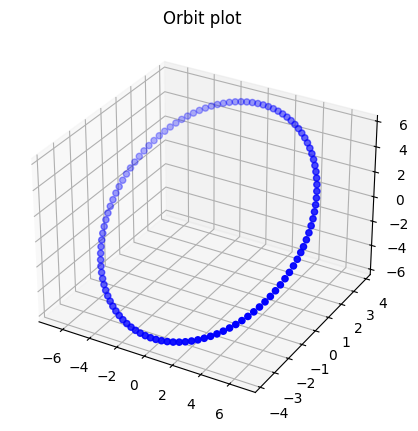

In [21]:
h = 50         # stepsize can be huge, since there is no dependence on previous state
t_final = 92*60  # 90 minutes (almost one full orbit)
steps = int(t_final / h)

t_orbit = np.linspace(0, t_final, steps)
x_orbit = np.zeros((steps, 3))
v_orbit = np.zeros((steps, 3))
mag_orbit = np.zeros((steps, 3))

for i, t in enumerate(t_orbit):
    x, v = orbital_elements.evaluate(t)
    mag = evaluate_magnetic_field_inertial(x)

    x_orbit[i] = x
    v_orbit[i] = v
    mag_orbit[i] = mag

x_orbit /= 1000000

fig3d = plt.figure(figsize=(6, 5))
ax3d = fig3d.add_subplot(111, projection="3d")
ax3d.scatter(x_orbit[:, 0], x_orbit[:, 1], x_orbit[:, 2], c="b", marker="o")
ax3d.set_title("Orbit plot")

""" 
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ax1, ax2 = axs[0:2]

vnorm = [np.linalg.norm(v) for v in v_orbit]
ax1.plot(t_orbit, v_orbit[:, 0])
ax1.plot(t_orbit, v_orbit[:, 1])
ax1.plot(t_orbit, v_orbit[:, 2])
ax1.plot(t_orbit, vnorm, label="norm")
ax1.set_title("Velocity over time")

magnorm = [np.linalg.norm(mag) for mag in mag_orbit]
ax2.plot(t_orbit, mag_orbit[:, 0], label="x")
ax2.plot(t_orbit, mag_orbit[:, 1], label="y")
ax2.plot(t_orbit, mag_orbit[:, 2], label="z")
ax2.plot(t_orbit, magnorm, label="norm")
ax2.set_title("Magnetic field over time (ECI frame)")
ax2.legend() """
plt.show()

Including the rotational dynamics of the satellite is more complicated. Here it is necessary to use integration schemes. The state derivative function uses quaternions and angular velocity (omega) as state. It does also need the position, but I am cheating a little here by using the orbital elements function to find it. 

The angular velocity derivate also includes the control law which ensures the satellite will stop rotating at some point. 

In [4]:
def derivative(state, t):
    omega = state[0:3]
    q0123 = state[3:7]

    x, _ = orbital_elements.evaluate(t)
    B = evaluate_magnetic_field_inertial_quaternion(x, q0123)

    omegadot = omega_derivative(omega, B)
    q0123dot = quaternion_derivative(q0123, omega)

    return np.hstack([omegadot, q0123dot])

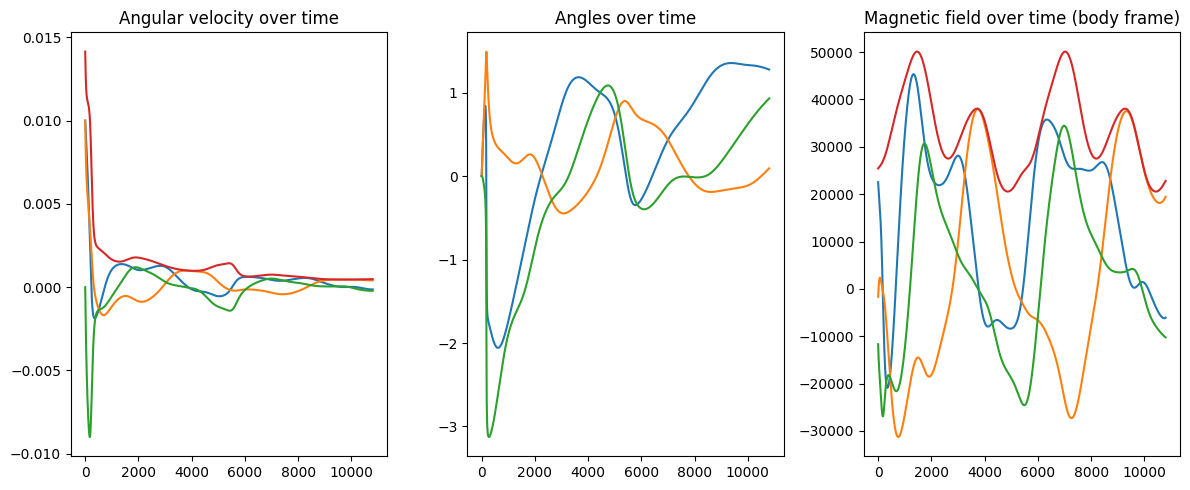

In [6]:
# initial conditions for rotational dynamics
q0123 = euler_to_quaternion([0, 0, 0])
omega = np.array([0.01, 0.01, 0])  # initial angular velocity

h = 1   # much smaller step size this time. It is still too big, but 
        # since the derivative function is so expensive, I'm not able 
        # to reduce it much without improving the code 
t_final = 5400*2
steps = int(t_final / h)
t_integrated = np.linspace(0, t_final, steps)
omega_integrated = np.zeros((steps, 3))
q0123_integrated = np.zeros((steps, 4))

mag_integrated = np.zeros((steps, 3))

state = np.hstack([omega, q0123])

for i, t in enumerate(t_integrated):
    q0123 = np.array(state[3:7])
    q0123 /= np.linalg.norm(q0123)  # Normalize quaternion
    state[3:7] = q0123

    omega_integrated[i] = np.array(state[0:3])
    q0123_integrated[i] = q0123

    x, _ = orbital_elements.evaluate(t)
    mag_integrated[i] = evaluate_magnetic_field_inertial_quaternion(x, q0123)

    # "classic" RK4 to integrate the rotational dynamics
    k1 = derivative(state, t)
    k2 = derivative(state + h * k1 / 2, t + h / 2)
    k3 = derivative(state + h * k2 / 2, t + h / 2)
    k4 = derivative(state + h * k3, t + h)

    state += (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

fig, axs = plt.subplots(1, 3, figsize=(12, 5))
ax1, ax2, ax3 = axs[0:3]

omeganorm = [np.linalg.norm(omega) for omega in omega_integrated]
ax1.plot(t_integrated, omega_integrated[:, 0])
ax1.plot(t_integrated, omega_integrated[:, 1])
ax1.plot(t_integrated, omega_integrated[:, 2])
ax1.plot(t_integrated, omeganorm, label="norm")
ax1.set_title("Angular velocity over time")

angles = np.array([quaternion_to_euler(q0123) for q0123 in q0123_integrated])
ax2.plot(t_integrated, angles[:, 0])
ax2.plot(t_integrated, angles[:, 1])
ax2.plot(t_integrated, angles[:, 2])
ax2.set_title("Angles over time")

magnorm = [np.linalg.norm(mag) for mag in mag_integrated]
ax3.plot(t_integrated, mag_integrated[:, 0])
ax3.plot(t_integrated, mag_integrated[:, 1])
ax3.plot(t_integrated, mag_integrated[:, 2])
ax3.plot(t_integrated, magnorm, label="norm")
ax3.set_title("Magnetic field over time (body frame)")


plt.tight_layout()
plt.show()


The angular velocity drops, which is a good sign. It should reach 0 with more orbits (assuming correct code).

The simulation does not include any noise or external influenses, which is expected in real scenarios. 